In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import glob
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union

In [2]:
train_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train'
val_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val'
test_dev_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev'
test_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge'

In [3]:
class_names = {
  0: "pedestrian",
  1: "people",
  2: "bicycle",
  3: "car",
  4: "van",
  5: "truck",
  6: "tricycle",
  7: "awning-tricycle",
  8: "bus",
  9: "motor"
}

In [4]:
def prepare_labelled_df(dataset_path: str, type: Union["training", "val", "test-dev"]) -> pd.DataFrame:
    files = glob.glob(f'{dataset_path}/labels/*.txt')
    rows = []
    for f in tqdm(files, f'Loading {type} annotations'):
        img_file = f.replace("labels", "images").replace(".txt", ".jpg")
        if not Path(img_file).exists():
            continue
        img = cv2.imread(img_file)
        h, w = img.shape[:2]
        
        df = pd.read_csv(f, sep=" ", names=["class", "x_center", "y_center", "width", "height"])
        df['file'] = f
        df['cn'] = df['class'].map(lambda i: class_names[i])
        df['img_width'] = w
        df['img_height'] = h
        df['box_width_px'] = df['width'] * w
        df['box_width_r'] = df['box_width_px'].round().astype(int)
        df['box_height_px'] = df['height'] * h
        df['box_height_r'] = df['box_height_px'].round().astype(int)
        df['area_px'] = df['box_width_px'] * df['box_height_px']
        df['area_int'] = df['box_width_r'] * df['box_height_r']
        
        rows.append(df)
        
    return pd.concat(rows, ignore_index=True)


        

In [5]:
train_df = prepare_labelled_df(train_dir, "training")

Loading training annotations: 100%|██████████| 6471/6471 [03:46<00:00, 28.61it/s]


In [6]:
val_df = prepare_labelled_df(val_dir, "val")

Loading val annotations: 100%|██████████| 548/548 [00:18<00:00, 30.19it/s]


In [7]:
test_dev_df = prepare_labelled_df(test_dev_dir, "test")

Loading test annotations: 100%|██████████| 1610/1610 [01:07<00:00, 23.92it/s]


In [8]:
def class_balance_check(df: pd.DataFrame, hue: str = None) -> None:
    ax = sns.histplot(
        data=df,
        x = 'cn',
        # order=df['cn'].value_counts().index,
        hue=hue,
        multiple='stack',
        kde=False,
        palette='viridis',
        discrete=True
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.show()

/tmp/ipykernel_57/2748455305.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(
/tmp/ipykernel_57/2748455305.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


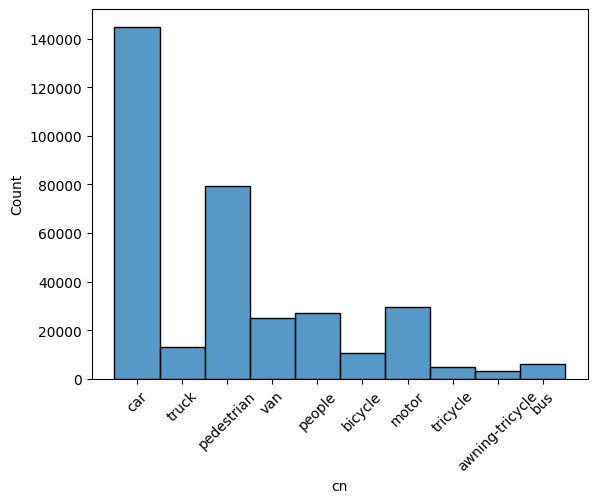

/tmp/ipykernel_57/2748455305.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(
/tmp/ipykernel_57/2748455305.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


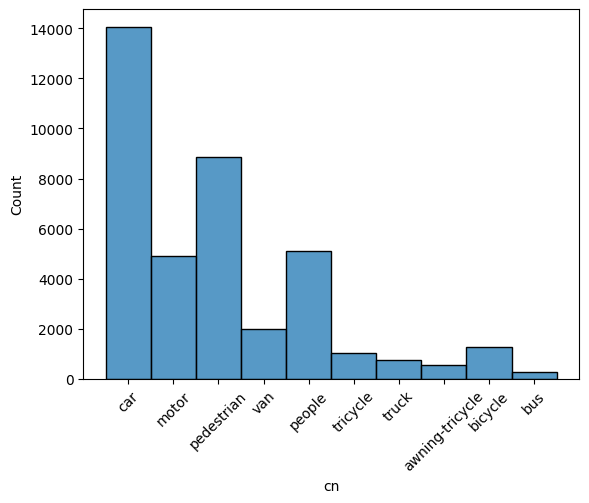

/tmp/ipykernel_57/2748455305.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(
/tmp/ipykernel_57/2748455305.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


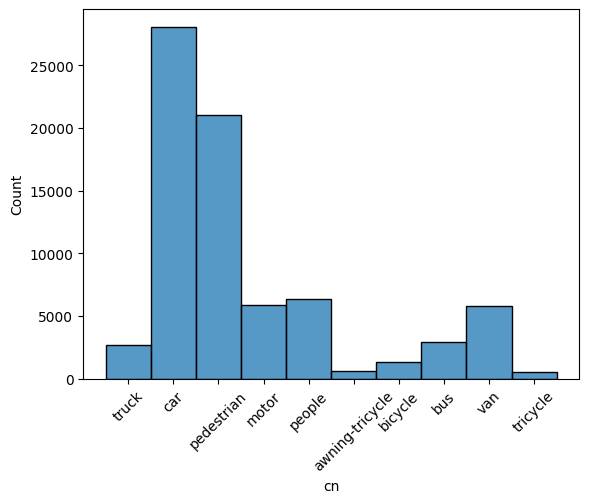

In [9]:
class_balance_check(train_df)
class_balance_check(val_df)
class_balance_check(test_dev_df)

In [10]:
def aspect_ratio_check(df: pd.DataFrame) -> None:
    df['aspect_ratio'] = df['box_width_px'] / df['box_height_r']
    sns.histplot(
        data=df,
        x='aspect_ratio',
        bins=50,
        hue='cn',
        multiple='stack',
        kde=True,
        log_scale=True
    )
    plt.show()

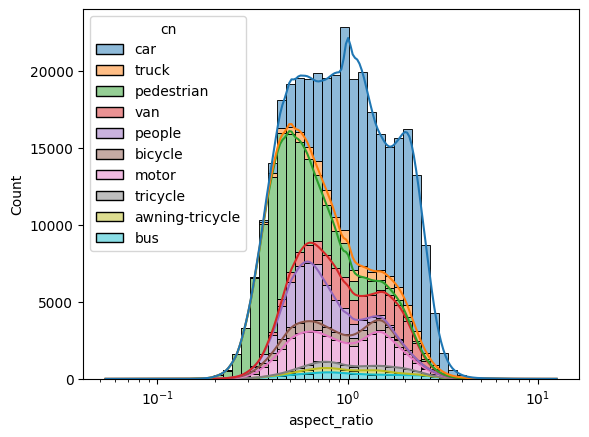

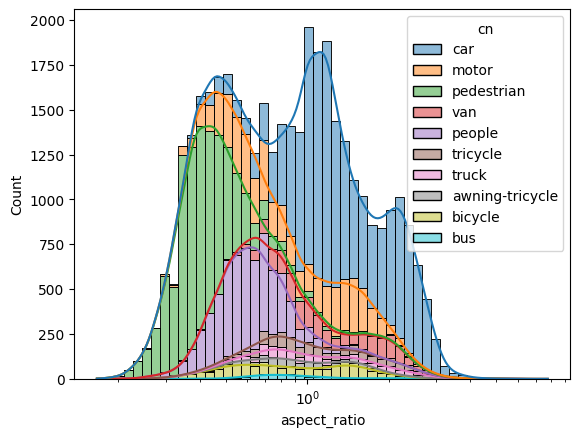

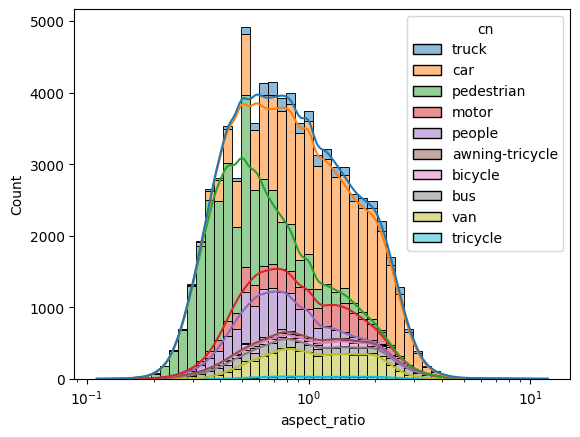

In [11]:
aspect_ratio_check(train_df)
aspect_ratio_check(val_df)
aspect_ratio_check(test_dev_df)

In [12]:
def bbox_check(df: pd.DataFrame) -> None:
    n = 3
    m = 2
    fig, ax = plt.subplots(m, n, figsize=(n * 6, m * 5))
    sns.histplot(
        data=df[df["box_width_r"] > 0],
        x='box_width_r',
        hue='cn',
        bins=50,
        multiple='stack',
        kde=True,
        log_scale=True,       
        ax=ax[0][0]
    )
    sns.histplot(
        data=df[df["box_height_r"] > 0],
        x='box_height_r',
        hue='cn',
        bins=50,
        multiple='stack',
        kde=True,
        log_scale=True,        
        ax=ax[0][1]
    )
    sns.histplot(
        data=df[df["area_int"] > 0],
        x='area_int',
        hue='cn',
        bins=50,
        multiple='stack',
        kde=True,
        log_scale=True,
        ax=ax[0][2]
    )
    sns.scatterplot(
        data=df,
        x='box_width_r',
        y='box_height_r',
        hue='cn',
        alpha=0.3,
        ax=ax[1][0]
    )
    heatmap, xedges, yedges = np.histogram2d(
        df['x_center'], df['y_center'], bins=50, range=[[0,1],[0,1]]
    )
    sns.heatmap(
        heatmap.T,
        cmap='magma',
        cbar=True,
        square=True,
        ax=ax[1][1]
    )
    ax[1][1].invert_yaxis()
    ax[1][1].set_xlabel("Normalized X (left → right)")
    ax[1][1].set_ylabel("Normalized Y (top → bottom)")
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.draw()
/tmp/ipykernel_57/2416546125.py:56: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


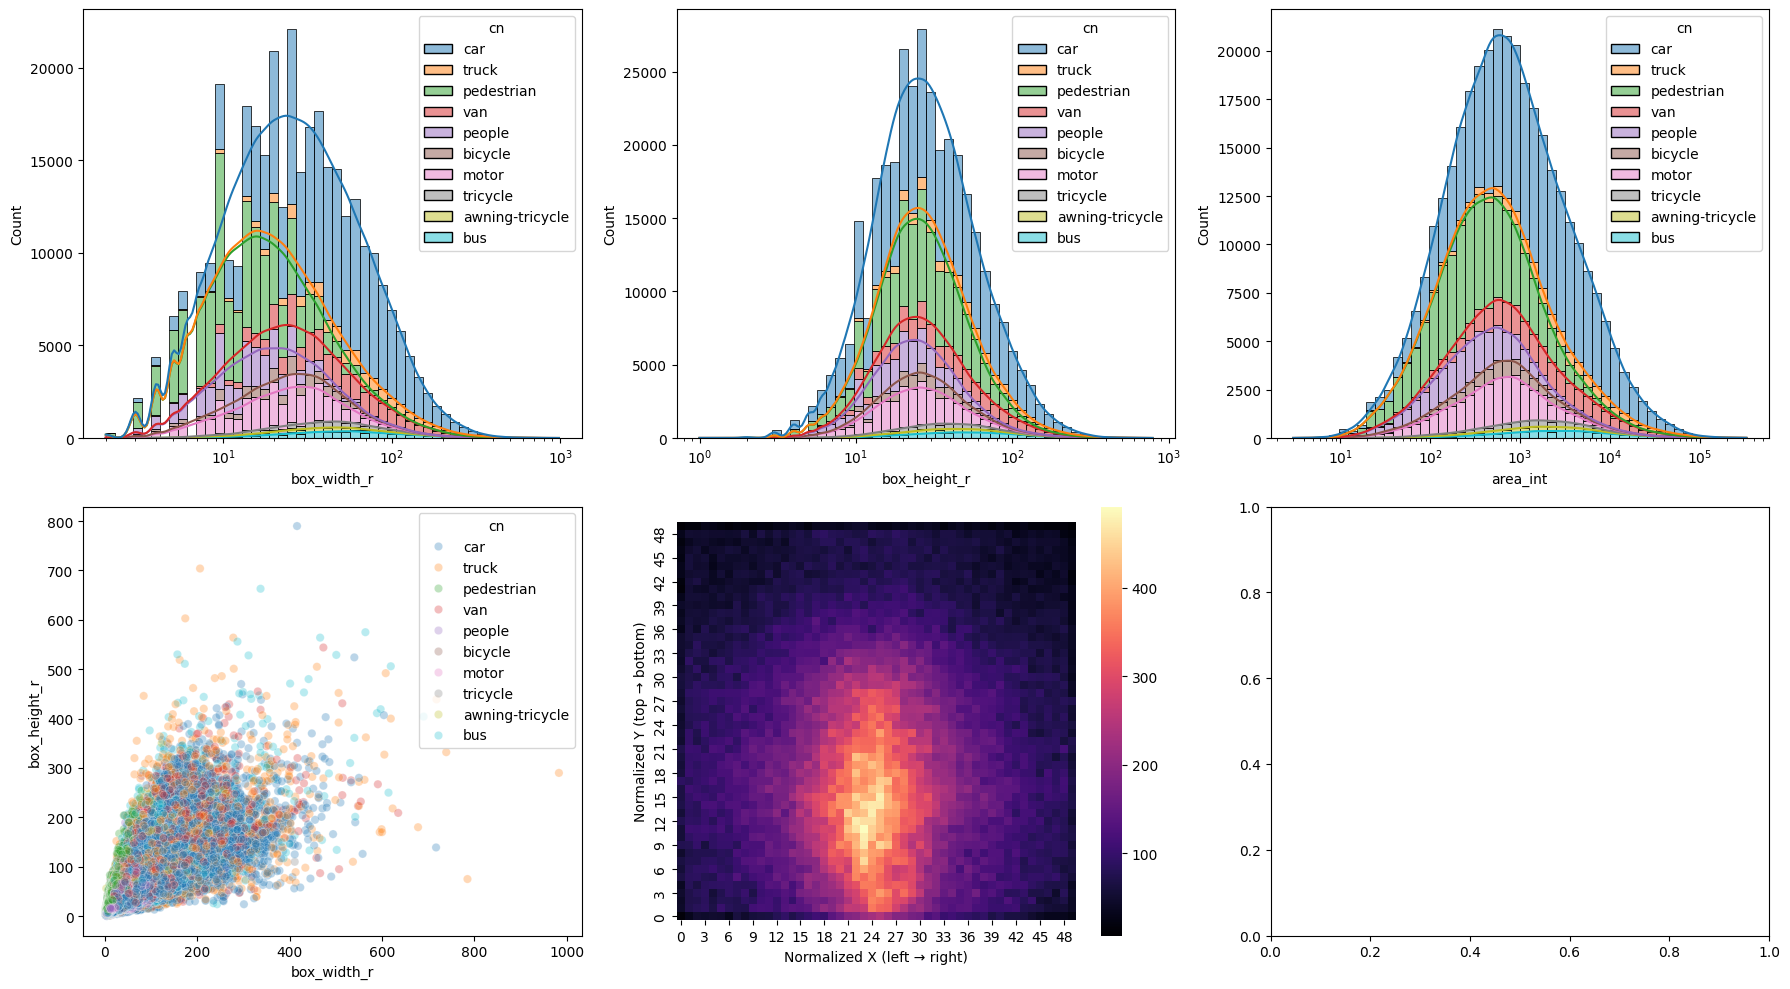

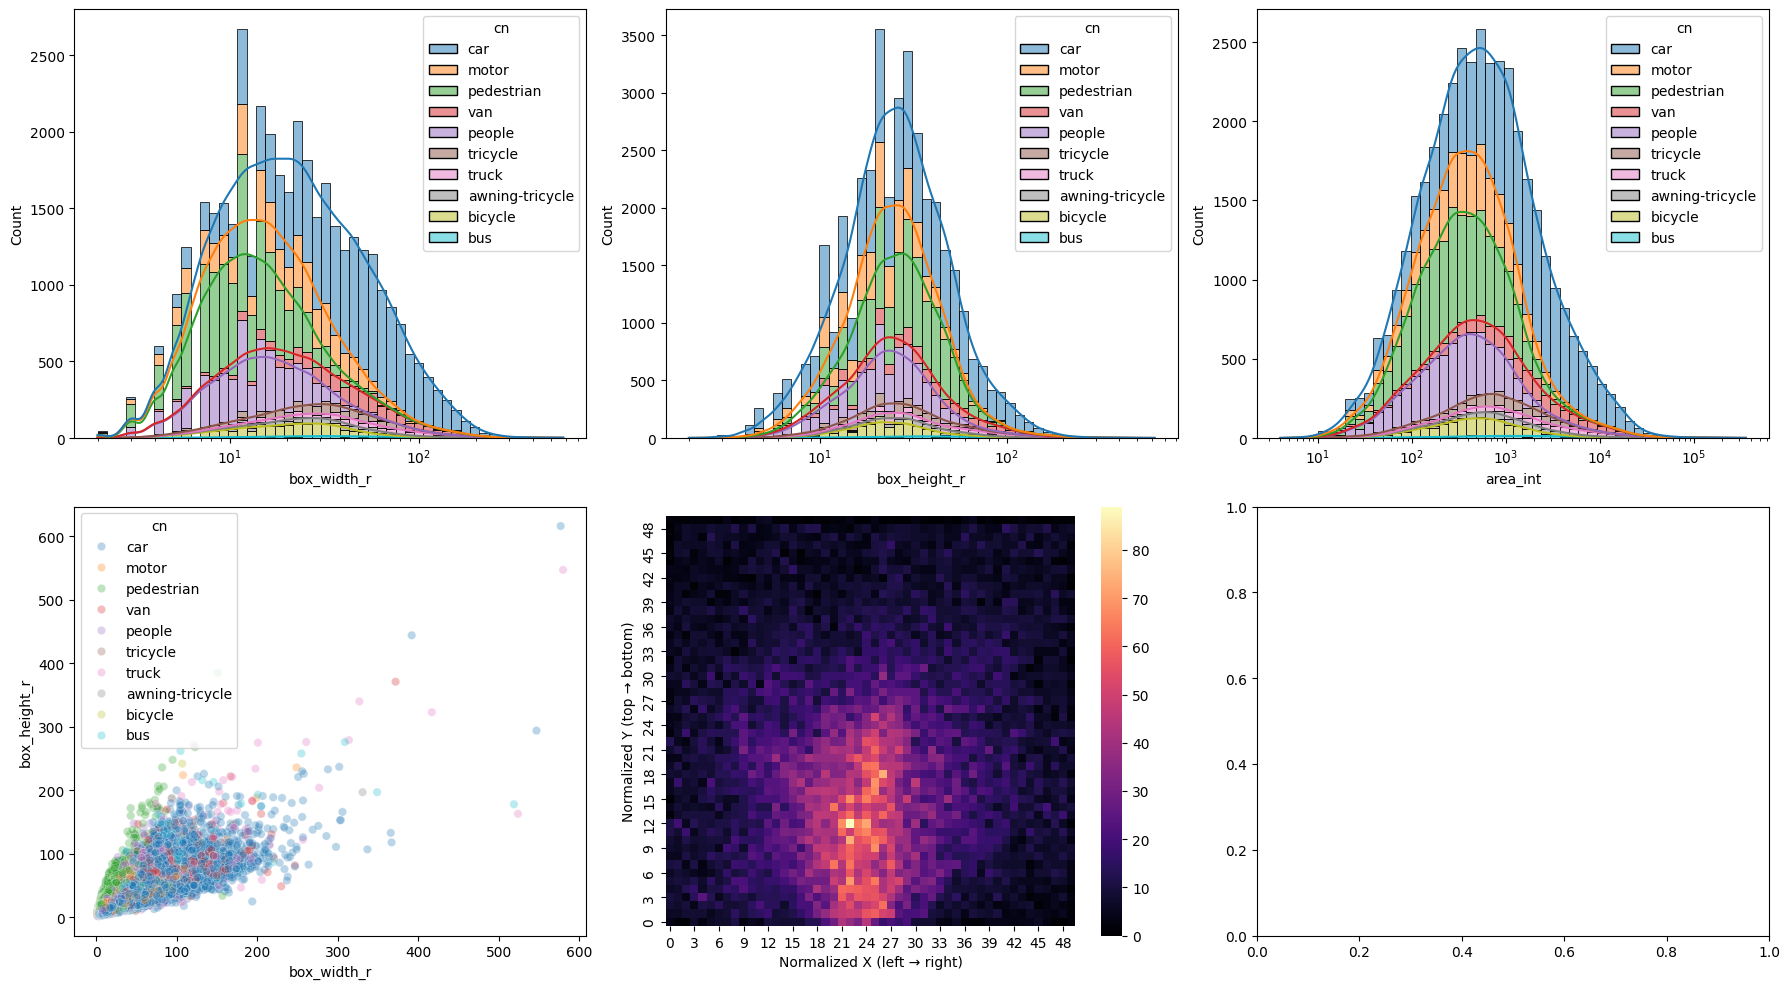

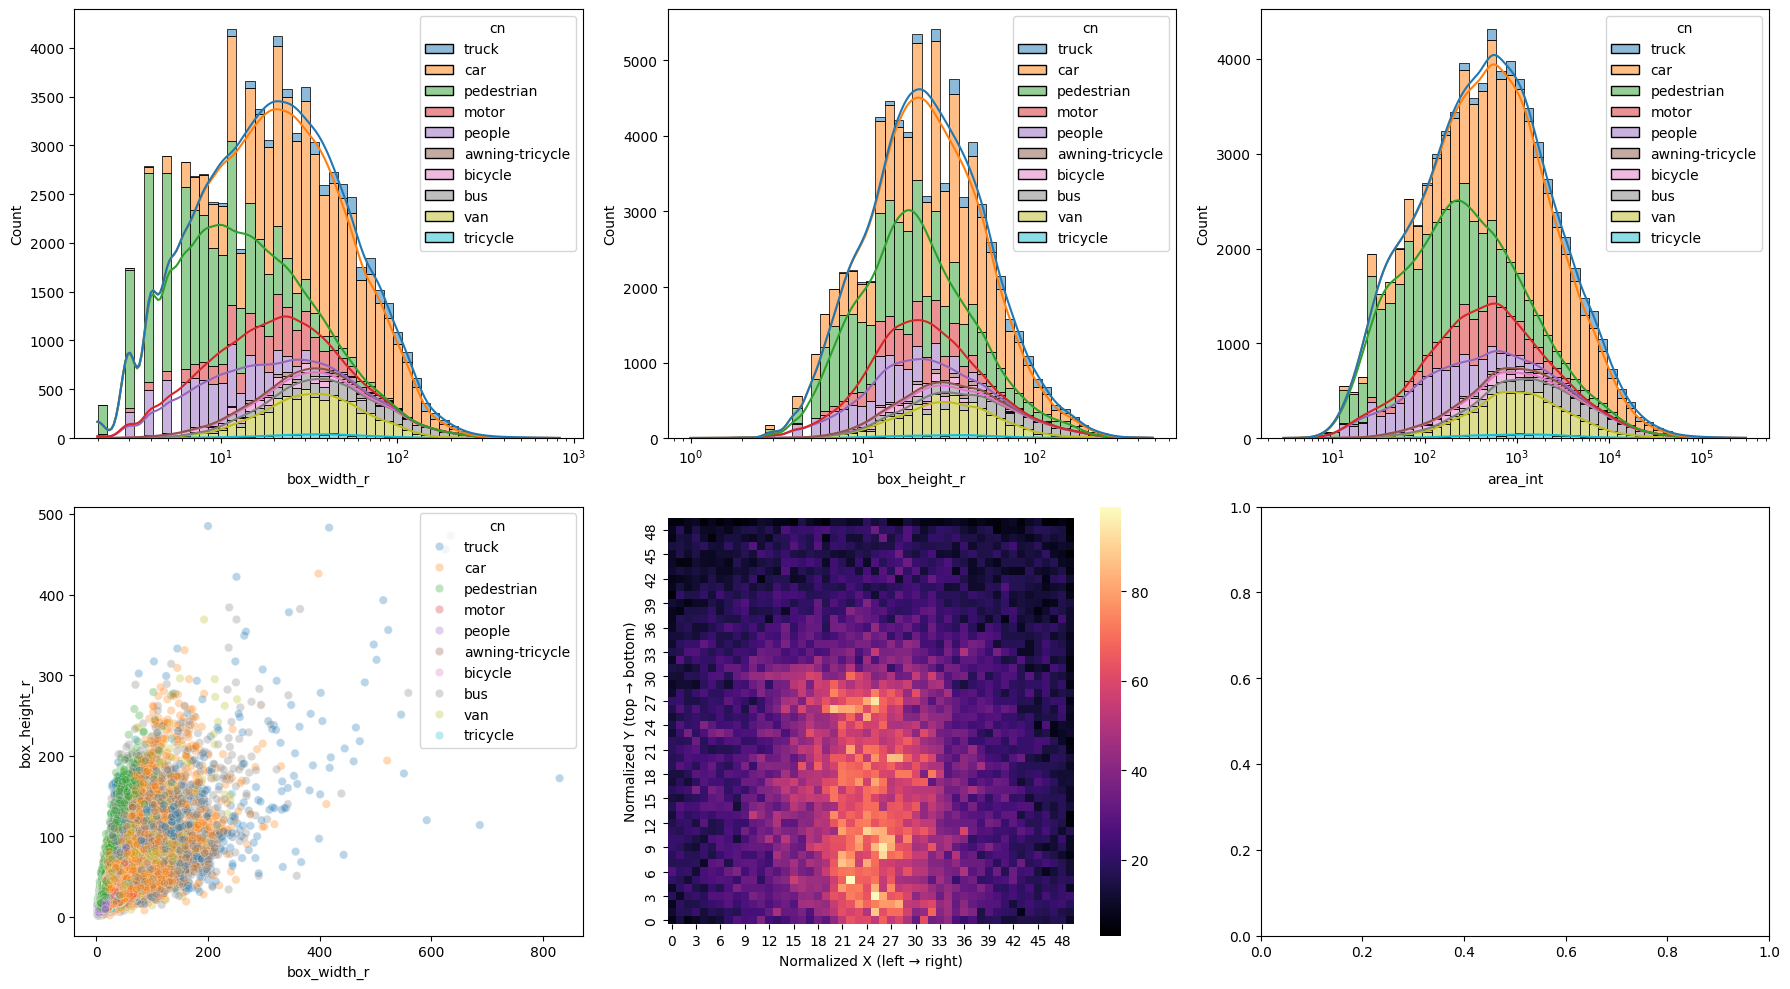

In [13]:
bbox_check(train_df)
bbox_check(val_df)
bbox_check(test_dev_df)

In [14]:
def object_count_check(df: pd.DataFrame) -> None:
    sns.histplot(
        df.groupby('file').size(),
        bins=100,
        kde=False,
        log_scale=True
    )
    plt.xlabel("Objects per image")
    plt.ylabel("Number of images")
    plt.show()

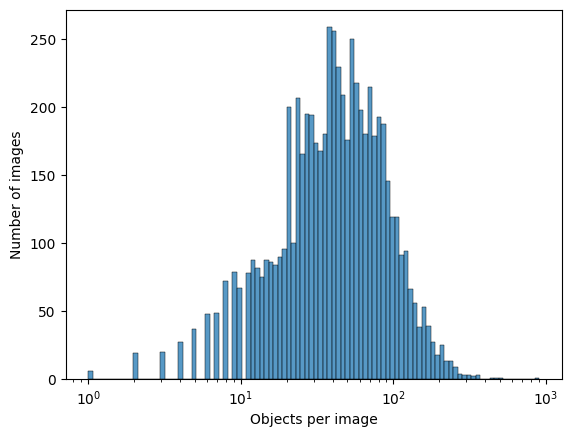

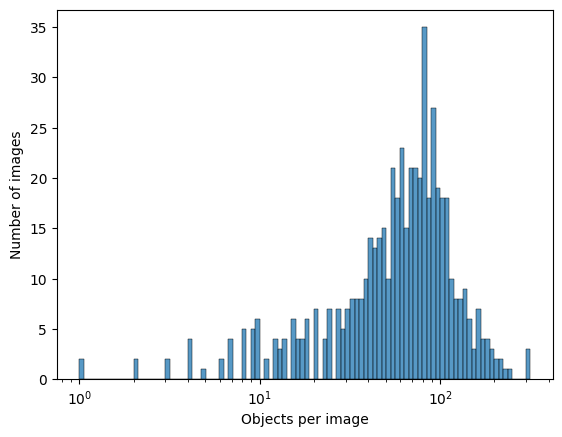

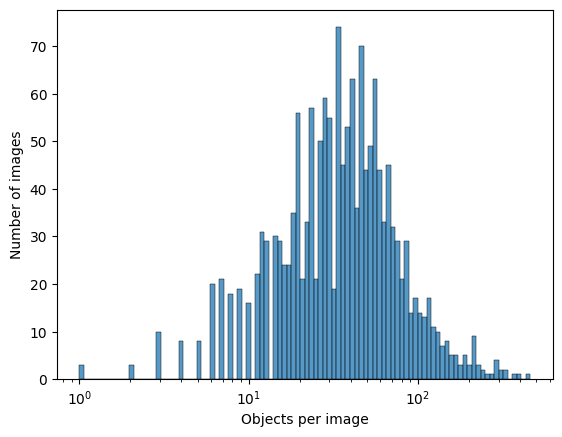

In [15]:
object_count_check(train_df)
object_count_check(val_df)
object_count_check(test_dev_df)

In [16]:
train_df['cn'].value_counts()

cn
car                144867
pedestrian          79337
motor               29647
people              27059
van                 24956
truck               12875
bicycle             10480
bus                  5926
tricycle             4812
awning-tricycle      3246
Name: count, dtype: int64